# 00 Data Exploration — M5 Retail Demand

This notebook is the first exploratory pass for the retail replenishment and allocation project. The goal is to understand the M5 Walmart dataset before moving into forecasting, inventory logic, or allocation rules.

Main objectives:
1. Understand how `Y_df`, `X_df`, and `S_df` fit together.
2. Audit the sales history and retail hierarchy.
3. Build clear category-level daily views for trend, seasonality, and low-sales diagnostics.
4. Keep the analysis portfolio-friendly and easy to extend later.


## 1. Setup


In [51]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SHARED_ROOT = None
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "helpers" / "__init__.py").exists():
        SHARED_ROOT = candidate
        break

if SHARED_ROOT is None:
    raise FileNotFoundError("Could not locate the shared portfolio helpers directory.")

if str(SHARED_ROOT) not in sys.path:
    sys.path.insert(0, str(SHARED_ROOT))

from helpers import (
    add_calendar_flags,
    bootstrap_notebook,
    finish_axis,
    plot_category_bar_panels,
    plot_category_histograms,
    plot_category_multiline,
    plot_category_panels,
)

notebook_context = bootstrap_notebook(Path.cwd())
PROJECT_ROOT = notebook_context.project_root
DATA_DIR = notebook_context.data_dir
PROCESSED_DIR = notebook_context.processed_dir
category_colors = notebook_context.category_colors


ModuleNotFoundError: No module named 'helpers'

## 2. Load M5 data

`datasetsforecast` returns three related tables:

- `Y_df`: the target sales history
- `X_df`: time-varying features such as sell price, events, and SNAP indicators
- `S_df`: static item/store/category metadata

We will inspect them separately first, then join them into one analytical table called `m5`.


In [2]:
from datasetsforecast.m5 import M5

Y_df, X_df, S_df = M5.load(directory=DATA_DIR, cache=True)

print("Y_df:", Y_df.shape)
print("X_df:", X_df.shape)
print("S_df:", S_df.shape)


Y_df: (47649940, 3)
X_df: (47649940, 10)
S_df: (30490, 6)


### Quick look at the three source tables


In [3]:
Y_df.head()


,unique_id,ds,y
0,FOODS_1_001_CA_1,2011-01-29,3.00
1,FOODS_1_001_CA_1,2011-01-30,0.00
2,FOODS_1_001_CA_1,2011-01-31,0.00
3,FOODS_1_001_CA_1,2011-02-01,1.00
4,FOODS_1_001_CA_1,2011-02-02,4.00


In [4]:
X_df.head()


,unique_id,ds,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1,2011-01-29,nan,nan,nan,nan,0,0,0,2.00
1,FOODS_1_001_CA_1,2011-01-30,nan,nan,nan,nan,0,0,0,2.00
2,FOODS_1_001_CA_1,2011-01-31,nan,nan,nan,nan,0,0,0,2.00
3,FOODS_1_001_CA_1,2011-02-01,nan,nan,nan,nan,1,1,0,2.00
4,FOODS_1_001_CA_1,2011-02-02,nan,nan,nan,nan,1,0,1,2.00


In [5]:
S_df.head()


,unique_id,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1969,FOODS_1_001_CA_2,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
3938,FOODS_1_001_CA_3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
5907,FOODS_1_001_CA_4,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
7875,FOODS_1_001_TX_1,FOODS_1_001,FOODS_1,FOODS,TX_1,TX


## 3. Initial schema and data quality audit

Before aggregating anything, confirm the basic structure of each table and check for obvious target issues such as duplicates, missing values, or negative sales.


In [6]:
for name, df in {"Y_df": Y_df, "X_df": X_df, "S_df": S_df}.items():
    print(f"\n{name}")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print(df.dtypes)



Y_df
shape: (47649940, 3)
columns: ['unique_id', 'ds', 'y']
unique_id          category
ds           datetime64[ns]
y                   float32
dtype: object

X_df
shape: (47649940, 10)
columns: ['unique_id', 'ds', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price']
unique_id             category
ds              datetime64[ns]
event_name_1          category
event_type_1          category
event_name_2          category
event_type_2          category
snap_CA                  uint8
snap_TX                  uint8
snap_WI                  uint8
sell_price             float32
dtype: object

S_df
shape: (30490, 6)
columns: ['unique_id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
unique_id    category
item_id      category
dept_id      category
cat_id       category
store_id     category
state_id     category
dtype: object


In [7]:
print("Date range:", Y_df["ds"].min(), "to", Y_df["ds"].max())
print("Number of unique series:", Y_df["unique_id"].nunique())
print("Rows:", len(Y_df))
print("Duplicate unique_id-date rows:", Y_df.duplicated(subset=["unique_id", "ds"]).sum())
print("Negative sales rows:", (Y_df["y"] < 0).sum())
print("Missing target values:", Y_df["y"].isna().sum())


Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00
Number of unique series: 30490
Rows: 47649940
Duplicate unique_id-date rows: 0
Negative sales rows: 0
Missing target values: 0


## 4. Create the main joined table

`m5` is the main SKU-store-day table used through the rest of the notebook. It combines:

- target sales from `Y_df`
- time-varying attributes from `X_df`
- static hierarchy attributes from `S_df`


In [8]:
# Join sales, time-varying features, and static hierarchy into one analytical table.
m5 = (
    Y_df
    .merge(X_df, on=["unique_id", "ds"], how="left")
    .merge(S_df, on="unique_id", how="left")
)

print("m5 shape:", m5.shape)
m5.head()


m5 shape: (47649940, 16)


,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.00,nan,nan,nan,nan,0,0,0,2.00,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.00,nan,nan,nan,nan,0,0,0,2.00,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.00,nan,nan,nan,nan,0,0,0,2.00,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.00,nan,nan,nan,nan,1,1,0,2.00,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.00,nan,nan,nan,nan,1,0,1,2.00,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [9]:
missing_summary = (
    m5.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_summary.head(25)


,column,missing_rate
0,unique_id,0.00
1,ds,0.00
2,y,0.00
3,event_name_1,0.00
4,event_type_1,0.00
5,event_name_2,0.00
6,event_type_2,0.00
7,snap_CA,0.00
8,snap_TX,0.00
9,snap_WI,0.00


In [10]:
series_lengths = (
    m5.groupby("unique_id", observed=True)["ds"]
    .agg(start_date="min", end_date="max", observations="count")
    .reset_index()
)

series_lengths.describe(include="all")


,unique_id,start_date,end_date,observations
count,30490,30490,30490,"30,490.00"
unique,30490,NaN,NaN,NaN
top,FOODS_1_001_CA_1,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,2012-03-10 04:40:03.935716608,2016-06-19 00:00:00.000000256,"1,562.81"
min,NaN,2011-01-29 00:00:00,2016-06-19 00:00:00,124.00
25%,NaN,2011-01-30 00:00:00,2016-06-19 00:00:00,"1,203.00"
50%,NaN,2011-07-07 00:00:00,2016-06-19 00:00:00,"1,810.00"
75%,NaN,2013-03-05 00:00:00,2016-06-19 00:00:00,"1,968.00"
max,NaN,2016-02-17 00:00:00,2016-06-19 00:00:00,"1,969.00"


## 5. Hierarchy exploration

The retail structure matters because this project will eventually move between SKU-store decisions and higher-level category signals. This section maps the hierarchy first.


In [11]:
hierarchy_cols = ["state_id", "store_id", "cat_id", "dept_id", "item_id"]

S_df[hierarchy_cols].nunique()


state_id       3
store_id      10
cat_id         3
dept_id        7
item_id     3049
dtype: int64

In [12]:
unique_values = {
    col: sorted(S_df[col].dropna().unique().tolist())
    for col in hierarchy_cols
}

# item_id is long, so preview only the first 20 values.
for col, values in unique_values.items():
    print(f"\n{col}: {len(values)} unique")
    print(values[:20])



state_id: 3 unique
['CA', 'TX', 'WI']

store_id: 10 unique
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

cat_id: 3 unique
['FOODS', 'HOBBIES', 'HOUSEHOLD']

dept_id: 7 unique
['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

item_id: 3049 unique
['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', 'FOODS_1_005', 'FOODS_1_006', 'FOODS_1_008', 'FOODS_1_009', 'FOODS_1_010', 'FOODS_1_011', 'FOODS_1_012', 'FOODS_1_013', 'FOODS_1_014', 'FOODS_1_015', 'FOODS_1_016', 'FOODS_1_017', 'FOODS_1_018', 'FOODS_1_019', 'FOODS_1_020', 'FOODS_1_021']


In [13]:
store_category_structure = (
    S_df
    .groupby(["state_id", "store_id", "cat_id"], observed=True)
    .agg(
        item_count=("item_id", "nunique"),
        series_count=("unique_id", "nunique"),
    )
    .reset_index()
    .sort_values(["state_id", "store_id", "cat_id"])
)

store_category_structure


,state_id,store_id,cat_id,item_count,series_count
0,CA,CA_1,HOBBIES,565,565
1,CA,CA_1,HOUSEHOLD,1047,1047
2,CA,CA_1,FOODS,1437,1437
3,CA,CA_2,HOBBIES,565,565
4,CA,CA_2,HOUSEHOLD,1047,1047
5,CA,CA_2,FOODS,1437,1437
6,CA,CA_3,HOBBIES,565,565
7,CA,CA_3,HOUSEHOLD,1047,1047
8,CA,CA_3,FOODS,1437,1437
9,CA,CA_4,HOBBIES,565,565


In [14]:
hierarchy_summary = (
    S_df
    .groupby(["state_id", "store_id", "cat_id", "dept_id"], observed=True)
    .agg(series_count=("unique_id", "nunique"))
    .reset_index()
    .sort_values(["state_id", "store_id", "cat_id", "dept_id"])
)

hierarchy_summary.head(25)


,state_id,store_id,cat_id,dept_id,series_count
0,CA,CA_1,HOBBIES,HOBBIES_1,416
1,CA,CA_1,HOBBIES,HOBBIES_2,149
2,CA,CA_1,HOUSEHOLD,HOUSEHOLD_1,532
3,CA,CA_1,HOUSEHOLD,HOUSEHOLD_2,515
4,CA,CA_1,FOODS,FOODS_1,216
5,CA,CA_1,FOODS,FOODS_2,398
6,CA,CA_1,FOODS,FOODS_3,823
7,CA,CA_2,HOBBIES,HOBBIES_1,416
8,CA,CA_2,HOBBIES,HOBBIES_2,149
9,CA,CA_2,HOUSEHOLD,HOUSEHOLD_1,532


## 6. Build the core category-level views

We keep three related category-level tables throughout the notebook:

- `category_daily_raw`: the source-of-truth category-day sales table with all dates retained
- `category_daily_event_adjusted`: the same sales totals enriched with event and calendar flags for diagnostics
- `category_daily_normalized`: a diagnostic-only view that excludes December 25 so one extreme holiday does not dominate certain charts

Important: December 25 is **not** deleted from the raw data. It stays in the raw and event-aware views. It is only excluded from the normalized diagnostic view.


In [15]:
# Raw category view: this keeps every observed category-day exactly as loaded.
category_daily_raw = (
    m5
    .groupby(["ds", "cat_id"], observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
    .sort_values(["cat_id", "ds"])
)

# Event columns are date-level, so deduplicate them before joining onto category totals.
calendar_daily = (
    X_df[["ds", "event_name_1", "event_type_1", "event_name_2", "event_type_2"]]
    .drop_duplicates()
    .sort_values("ds")
)

assert calendar_daily["ds"].is_unique, "Expected one calendar row per date."

# Event-adjusted means calendar-aware for diagnostics; sales values are not mathematically altered here.
category_daily_event_adjusted = add_calendar_flags(
    category_daily_raw.merge(calendar_daily, on="ds", how="left")
).sort_values(["cat_id", "ds"])

# Normalized view is diagnostic only: exclude Dec 25 to inspect typical demand without one extreme holiday dominating.
category_daily_normalized = category_daily_event_adjusted.loc[
    ~category_daily_event_adjusted["is_christmas"]
].copy()

view_summary = pd.DataFrame(
    [
         {
             "view_name": "category_daily_raw",
             "rows": len(category_daily_raw),
            "includes_dec_25": (
                category_daily_raw["ds"].dt.month.eq(12)
                & category_daily_raw["ds"].dt.day.eq(25)
            ).any(),
             "purpose": "Source-of-truth category sales history",
         },
        {
            "view_name": "category_daily_event_adjusted",
            "rows": len(category_daily_event_adjusted),
            "includes_dec_25": category_daily_event_adjusted["is_christmas"].any(),
            "purpose": "Same sales totals plus event and calendar flags",
        },
        {
            "view_name": "category_daily_normalized",
            "rows": len(category_daily_normalized),
            "includes_dec_25": category_daily_normalized["is_christmas"].any(),
            "purpose": "Diagnostic view excluding Dec 25 only",
        },
    ]
)

view_summary


,view_name,rows,includes_dec_25,purpose
0,category_daily_raw,5907,True,Source-of-truth category sales history
1,category_daily_event_adjusted,5907,True,Same sales totals plus event and calendar flags
2,category_daily_normalized,5892,False,Diagnostic view excluding Dec 25 only


In [16]:
# These lower-level aggregates will be useful later for supply-chain diagnostics.
store_category_daily = (
    m5
    .groupby(["ds", "state_id", "store_id", "cat_id"], observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
    .sort_values(["state_id", "store_id", "cat_id", "ds"])
)

state_category_daily = (
    m5
    .groupby(["ds", "state_id", "cat_id"], observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
    .sort_values(["state_id", "cat_id", "ds"])
)

store_category_daily.head()


,ds,state_id,store_id,cat_id,y
0,2011-01-29,CA,CA_1,HOBBIES,556.00
30,2011-01-30,CA,CA_1,HOBBIES,498.00
60,2011-01-31,CA,CA_1,HOBBIES,415.00
90,2011-02-01,CA,CA_1,HOBBIES,392.00
120,2011-02-02,CA,CA_1,HOBBIES,268.00


## 7. Total and category-level sales trends

Start with the most readable business view: total daily sales and category-level daily sales. This gives a first sense of overall scale, trend smoothness, and whether one category dominates the signal.


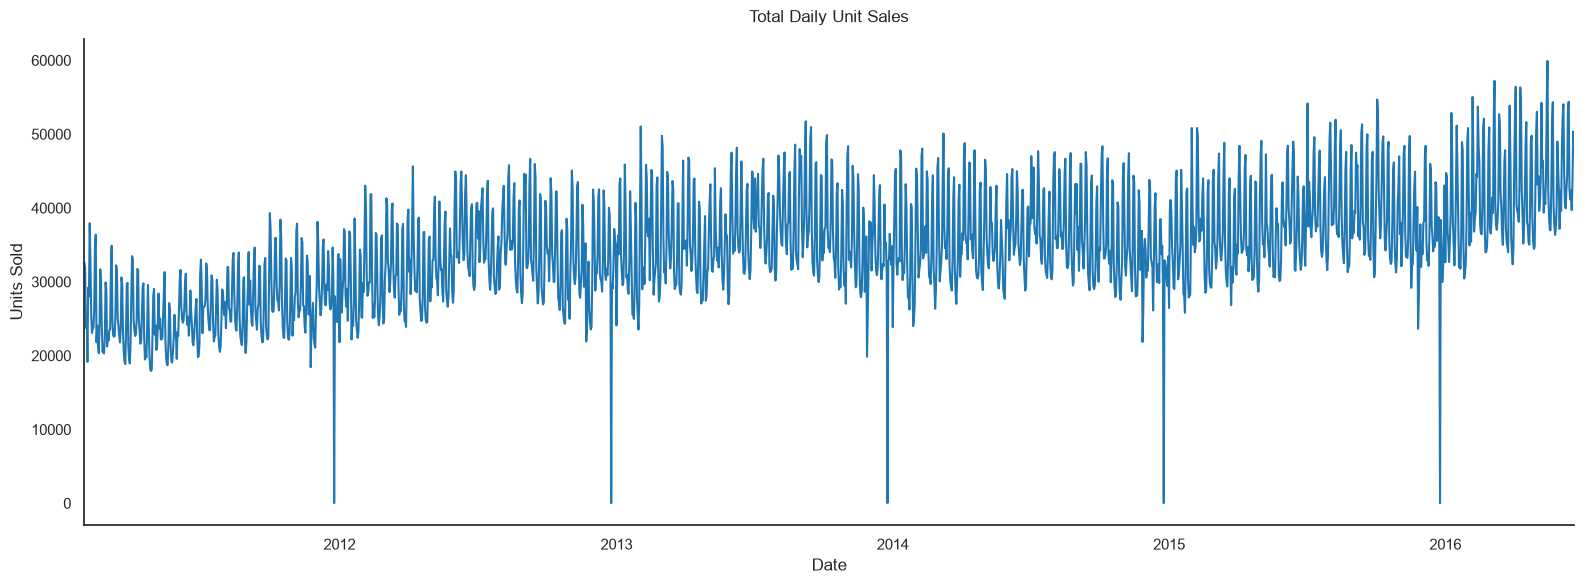

In [17]:
daily_sales = (
    category_daily_raw
    .groupby("ds", observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
)

ax = daily_sales.plot(x="ds", y="y", figsize=(16, 6), legend=False, color="tab:blue")
finish_axis(ax, title="Total Daily Unit Sales", xlabel="Date", ylabel="Units Sold")
plt.show()


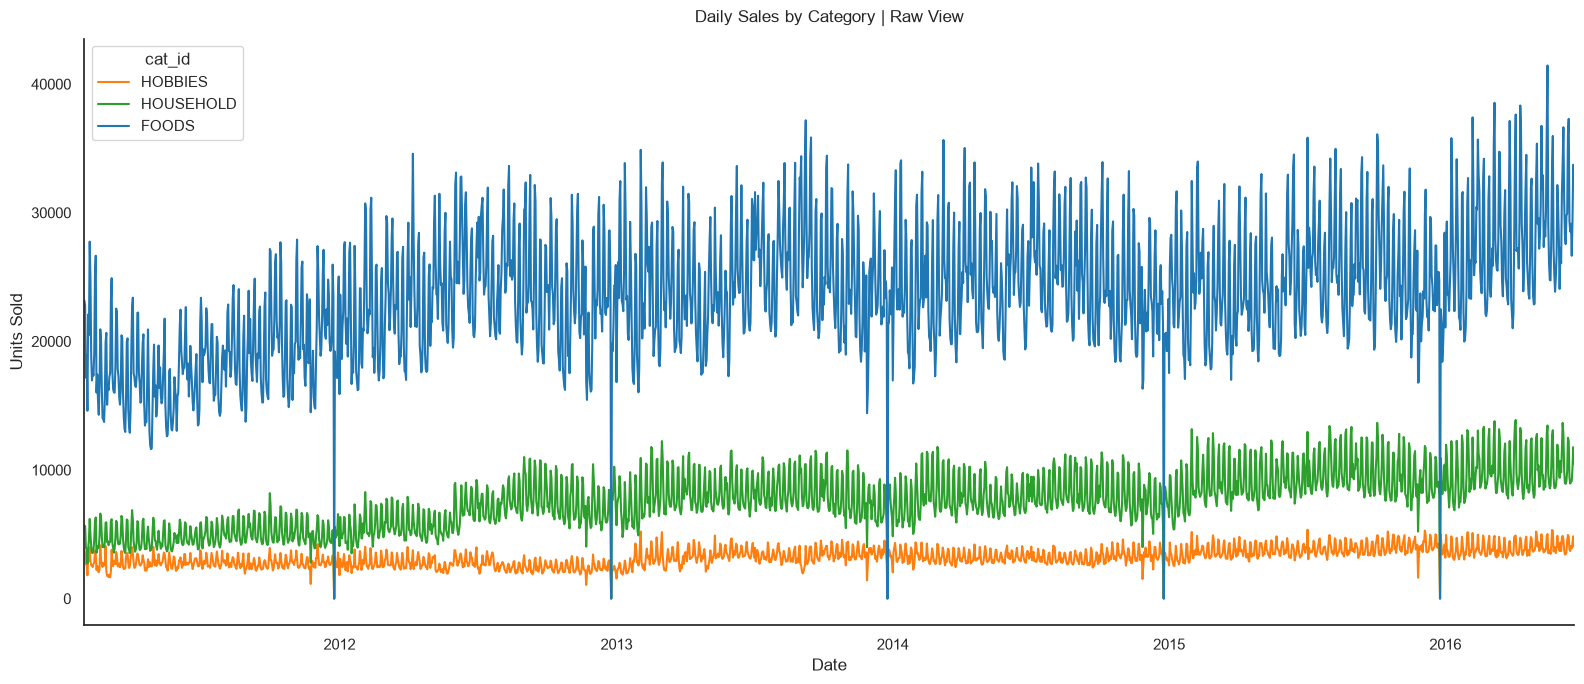

In [18]:
plot_category_multiline(category_daily_raw, title="Daily Sales by Category | Raw View")


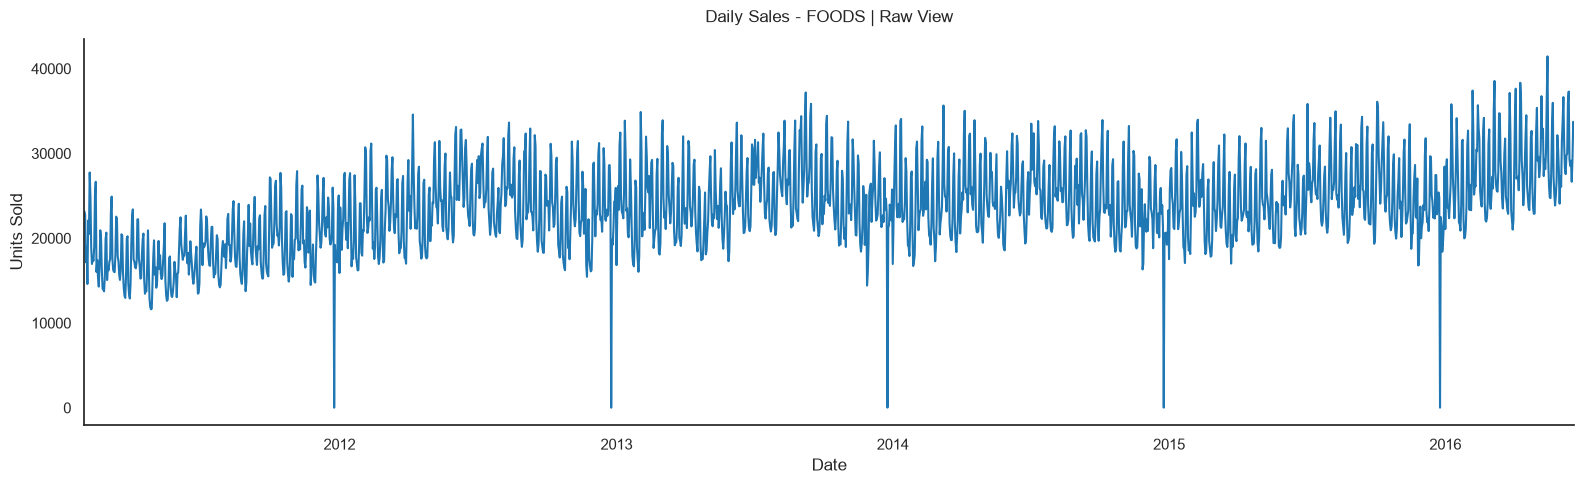

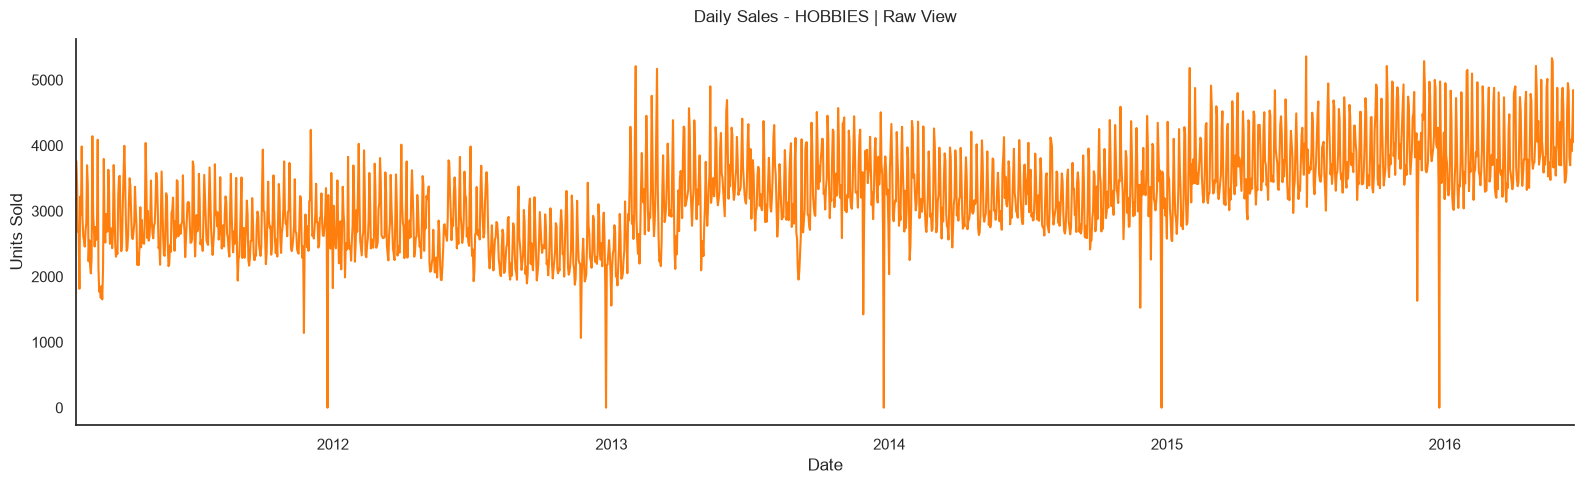

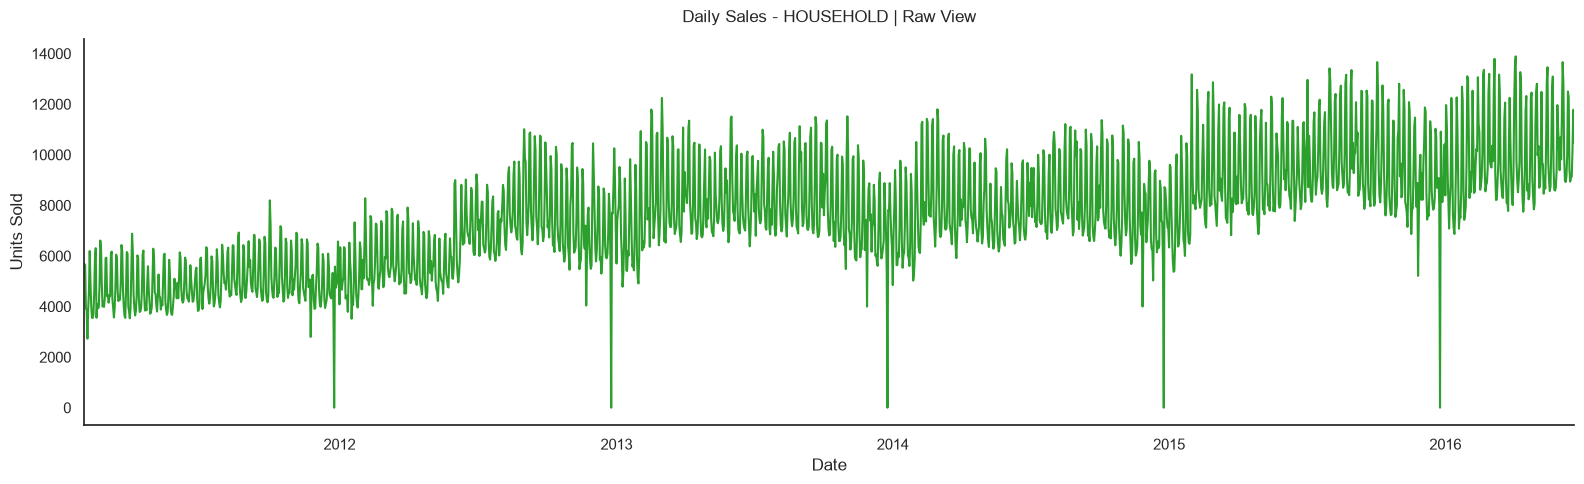

In [19]:
plot_category_panels(category_daily_raw, title_suffix="Raw View")


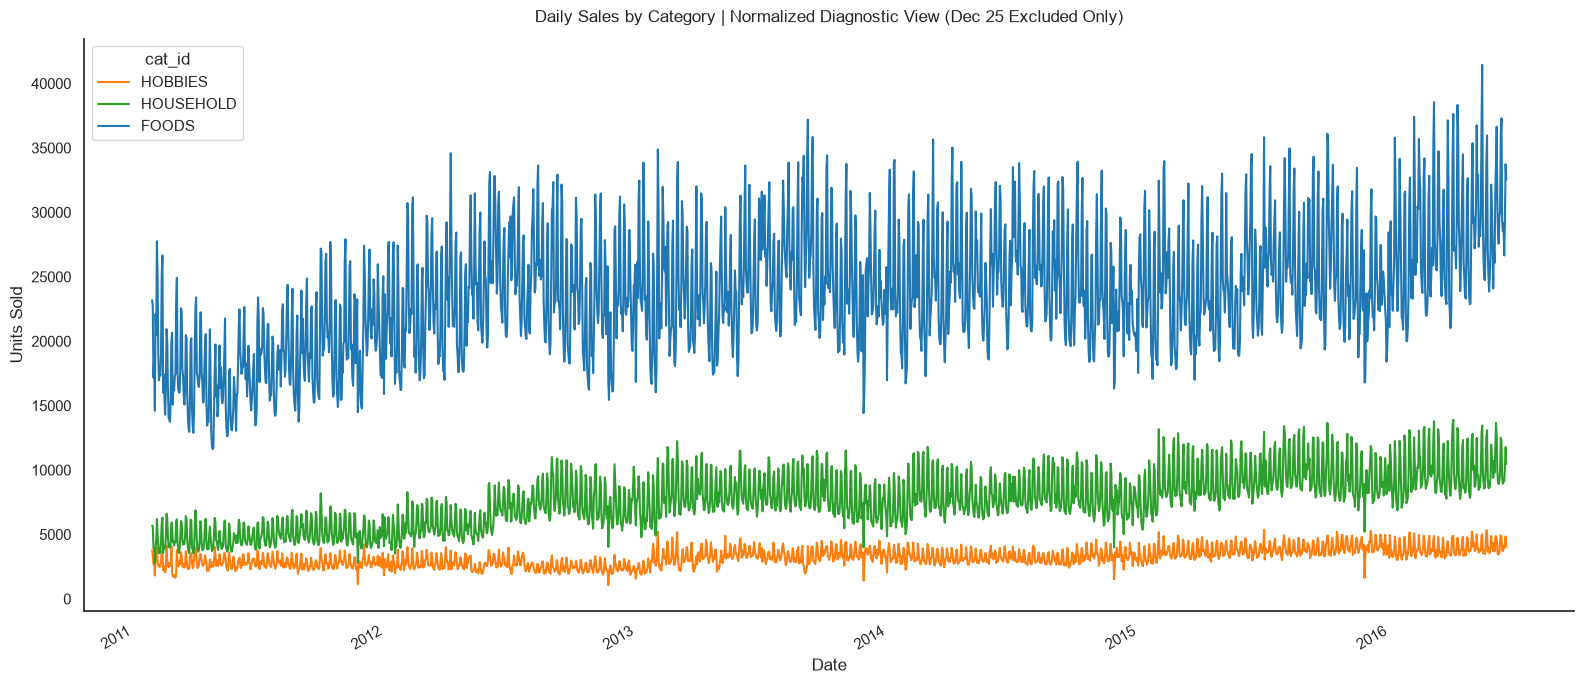

In [20]:
plot_category_multiline(category_daily_normalized, title="Daily Sales by Category | Normalized Diagnostic View (Dec 25 Excluded Only)")


## 8. Extreme low-sales days and holiday diagnostics

This section asks whether unusually low category days look like data errors, predictable holiday behavior, or narrower store-level effects. The goal is diagnosis, not a final causal claim.


In [21]:
zero_category_days = category_daily_raw.loc[category_daily_raw["y"].eq(0)].copy()

print("Zero category-day observations:", len(zero_category_days))
zero_category_days.sort_values(["ds", "cat_id"])


Zero category-day observations: 9


,ds,cat_id,y
990,2011-12-25,HOBBIES,0.00
991,2011-12-25,HOUSEHOLD,0.00
2088,2012-12-25,HOBBIES,0.00
2089,2012-12-25,HOUSEHOLD,0.00
3183,2013-12-25,HOBBIES,0.00
3184,2013-12-25,HOUSEHOLD,0.00
4278,2014-12-25,HOBBIES,0.00
4279,2014-12-25,HOUSEHOLD,0.00
5373,2015-12-25,HOBBIES,0.00


In [22]:
low_sales_days = (
    category_daily_event_adjusted
    .assign(
        p01_by_category=lambda df: (
            df.groupby("cat_id", observed=True)["y"]
            .transform(lambda s: s.quantile(0.01))
        )
    )
    .loc[lambda df: df["y"] <= df["p01_by_category"]]
    .sort_values(["cat_id", "y", "ds"])
)

low_sales_days


,ds,cat_id,y,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_christmas,is_christmas_eve,is_day_after_christmas,is_new_years_day,is_thanksgiving_window,p01_by_category
330,2011-12-25,HOBBIES,0.00,Christmas,National,nan,nan,2011,12,25,Sunday,51,True,False,False,False,False,"1,872.48"
696,2012-12-25,HOBBIES,0.00,Christmas,National,nan,nan,2012,12,25,Tuesday,52,True,False,False,False,False,"1,872.48"
1061,2013-12-25,HOBBIES,0.00,Christmas,National,nan,nan,2013,12,25,Wednesday,52,True,False,False,False,False,"1,872.48"
1426,2014-12-25,HOBBIES,0.00,Christmas,National,nan,nan,2014,12,25,Thursday,52,True,False,False,False,False,"1,872.48"
1791,2015-12-25,HOBBIES,0.00,Christmas,National,nan,nan,2015,12,25,Friday,52,True,False,False,False,False,"1,872.48"
663,2012-11-22,HOBBIES,"1,064.00",Thanksgiving,National,nan,nan,2012,11,22,Thursday,47,False,False,False,False,True,"1,872.48"
299,2011-11-24,HOBBIES,"1,140.00",Thanksgiving,National,nan,nan,2011,11,24,Thursday,47,False,False,False,False,True,"1,872.48"
1034,2013-11-28,HOBBIES,"1,424.00",Thanksgiving,National,nan,nan,2013,11,28,Thursday,48,False,False,False,False,True,"1,872.48"
1398,2014-11-27,HOBBIES,"1,525.00",Thanksgiving,National,nan,nan,2014,11,27,Thursday,48,False,False,False,False,True,"1,872.48"
703,2013-01-01,HOBBIES,"1,558.00",NewYear,National,nan,nan,2013,1,1,Tuesday,1,False,False,False,True,False,"1,872.48"


In [23]:
christmas_impact = (
    category_daily_event_adjusted
    .groupby(["cat_id", "is_christmas"], observed=True)["y"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reset_index()
)

christmas_impact_pivot = (
    christmas_impact
    .pivot(index="cat_id", columns="is_christmas", values="mean")
    .rename(columns={False: "normal_avg_sales", True: "christmas_avg_sales"})
)

christmas_impact_pivot["christmas_sales_retention"] = (
    christmas_impact_pivot["christmas_avg_sales"] / christmas_impact_pivot["normal_avg_sales"]
)
christmas_impact_pivot["christmas_sales_drop_pct"] = 1 - christmas_impact_pivot["christmas_sales_retention"]

christmas_impact_pivot.round(3)


is_christmas,normal_avg_sales,christmas_avg_sales,christmas_sales_retention,christmas_sales_drop_pct
cat_id,,,,
HOBBIES,"3,236.24",0.00,0.00,1.00
HOUSEHOLD,"7,663.34",0.20,0.00,1.00
FOODS,"23,803.19",15.40,0.00,1.00


In [24]:
# Drill deeper into Christmas to avoid assuming that all stores are simply "closed."
christmas_detail = m5.loc[
    m5["ds"].dt.month.eq(12)
    & m5["ds"].dt.day.eq(25)
    & m5["y"].gt(0)
].copy()

christmas_store_sales = (
    christmas_detail
    .assign(year=lambda df: df["ds"].dt.year)
    .groupby(["year", "cat_id", "state_id", "store_id"], observed=True)
    .agg(
        total_sales=("y", "sum"),
        selling_items=("item_id", "nunique"),
        selling_series=("unique_id", "nunique"),
    )
    .reset_index()
    .sort_values(["year", "cat_id", "total_sales"], ascending=[True, True, False])
)

christmas_store_sales.head(20)


,year,cat_id,state_id,store_id,total_sales,selling_items,selling_series
0,2011,FOODS,CA,CA_2,7.00,2,2
3,2011,FOODS,WI,WI_2,3.00,3,3
2,2011,FOODS,TX,TX_3,2.00,2,2
1,2011,FOODS,CA,CA_3,1.00,1,1
5,2012,FOODS,CA,CA_3,4.00,4,4
7,2012,FOODS,WI,WI_2,3.00,3,3
4,2012,FOODS,CA,CA_2,2.00,2,2
6,2012,FOODS,TX,TX_3,2.00,2,2
11,2013,FOODS,TX,TX_2,11.00,4,4
9,2013,FOODS,CA,CA_3,3.00,2,2


In [25]:
christmas_category_summary = (
    christmas_store_sales
    .groupby(["year", "cat_id"], observed=True)
    .agg(
        stores_with_sales=("store_id", "nunique"),
        total_christmas_sales=("total_sales", "sum"),
        total_selling_items=("selling_items", "sum"),
        total_selling_series=("selling_series", "sum"),
    )
    .reset_index()
)

christmas_category_summary


,year,cat_id,stores_with_sales,total_christmas_sales,total_selling_items,total_selling_series
0,2011,FOODS,4,13.00,8,8
1,2012,FOODS,4,11.00,11,11
2,2013,FOODS,7,20.00,12,12
3,2014,FOODS,4,20.00,17,17
4,2015,HOUSEHOLD,1,1.00,1,1
5,2015,FOODS,7,13.00,11,11


In [26]:
thanksgiving_impact = (
    category_daily_event_adjusted
    .groupby(["cat_id", "is_thanksgiving_window"], observed=True)["y"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reset_index()
)

thanksgiving_impact


,cat_id,is_thanksgiving_window,count,mean,median,min,max
0,HOBBIES,False,1934,"3,233.82","3,205.50",0.00,"5,360.00"
1,HOBBIES,True,35,"2,907.77","2,948.00","1,064.00","4,817.00"
2,HOUSEHOLD,False,1934,"7,658.92","7,514.50",0.00,"13,889.00"
3,HOUSEHOLD,True,35,"6,812.86","6,695.00","2,798.00","11,469.00"
4,FOODS,False,1934,"23,802.88","23,443.50",11.00,"41,447.00"
5,FOODS,True,35,"20,421.83","20,047.00","14,419.00","28,639.00"


### Working interpretation

December 25 should not automatically be treated as bad data or confirmed store closure. The raw data keeps those observations, and some sales still appear on that date. For this notebook, December 25 is excluded only in `category_daily_normalized`, which is a diagnostic view for studying typical demand without one extreme holiday dominating the scale.


## 9. Sales distribution analysis

Distribution views help show how different the categories are in scale and spread. The raw view reflects real operating behavior, while the normalized view helps us inspect the shape of ordinary demand after removing December 25 from that one diagnostic slice.


In [27]:
category_summary_raw = (
    category_daily_raw
    .groupby("cat_id", observed=True)["y"]
    .agg(count="count", mean="mean", median="median", std="std", skew="skew", min="min", max="max")
    .round(2)
)

category_summary_raw


,count,mean,median,std,skew,min,max
cat_id,,,,,,,
HOBBIES,1969,"3,228.02","3,203.00",718.74,0.13,0.00,"5,360.00"
HOUSEHOLD,1969,"7,643.88","7,494.00","2,222.21",0.22,0.00,"13,889.00"
FOODS,1969,"23,742.78","23,377.00","4,990.16",0.02,11.00,"41,447.00"


In [28]:
category_summary_normalized = (
    category_daily_normalized
    .groupby("cat_id", observed=True)["y"]
    .agg(count="count", mean="mean", median="median", std="std", skew="skew", min="min", max="max")
    .round(2)
)

category_summary_normalized


,count,mean,median,std,skew,min,max
cat_id,,,,,,,
HOBBIES,1964,"3,236.24","3,204.50",700.92,0.35,"1,064.00","5,360.00"
HOUSEHOLD,1964,"7,663.34","7,504.00","2,191.26",0.31,"2,729.00","13,889.00"
FOODS,1964,"23,803.19","23,386.00","4,850.51",0.28,"11,616.00","41,447.00"


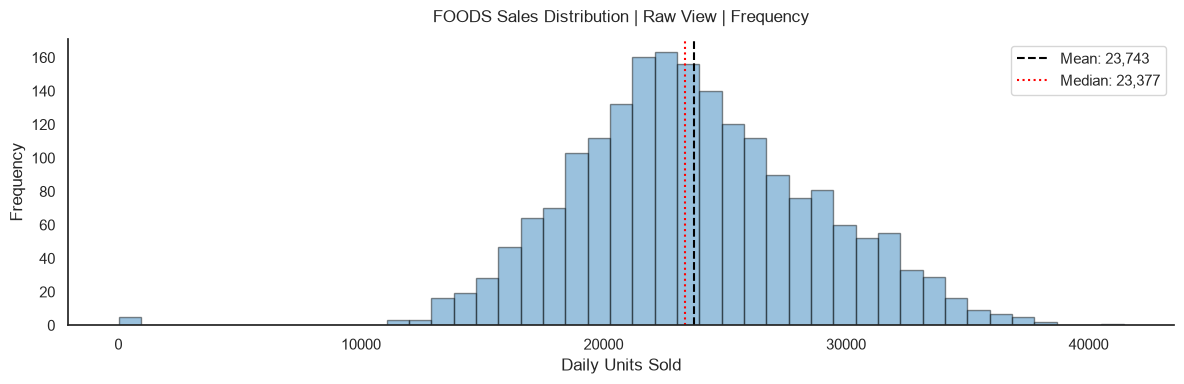

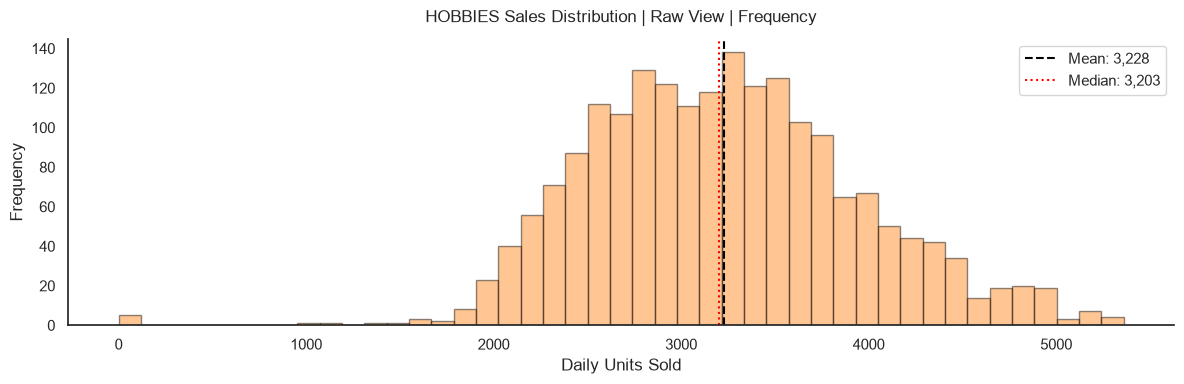

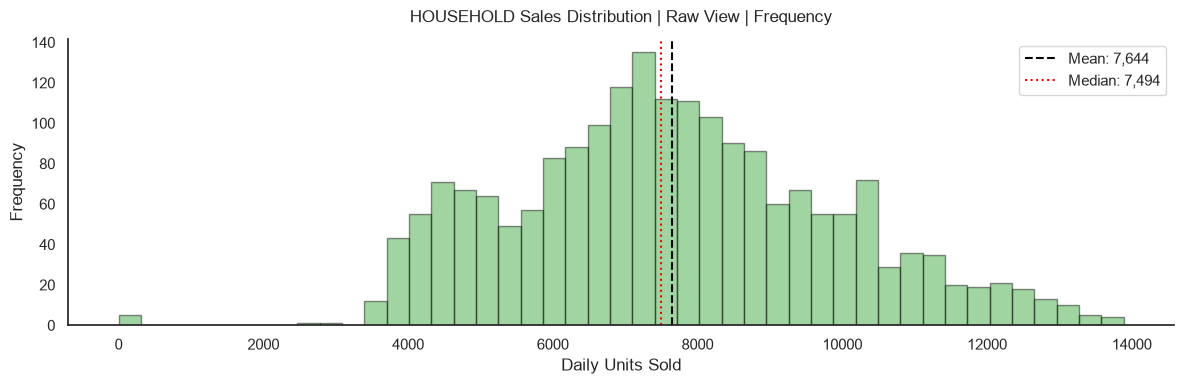

In [29]:
plot_category_histograms(category_daily_raw, title_suffix="Raw View", density=False)


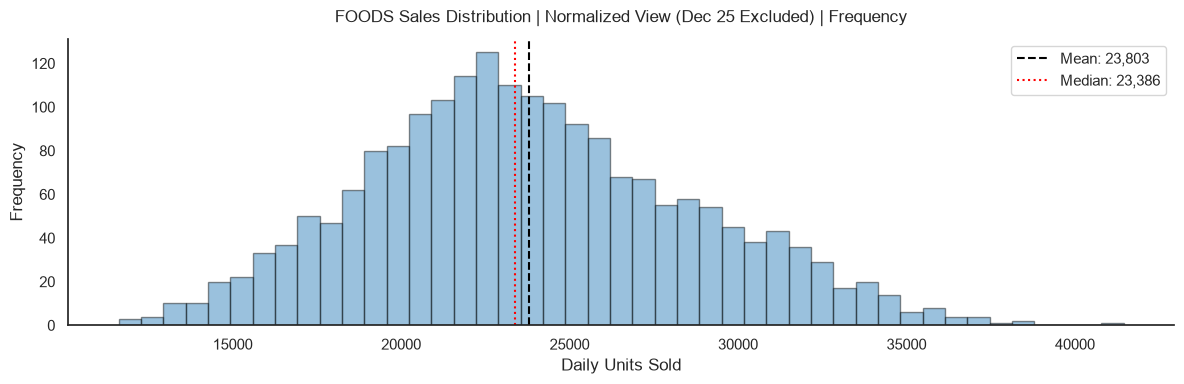

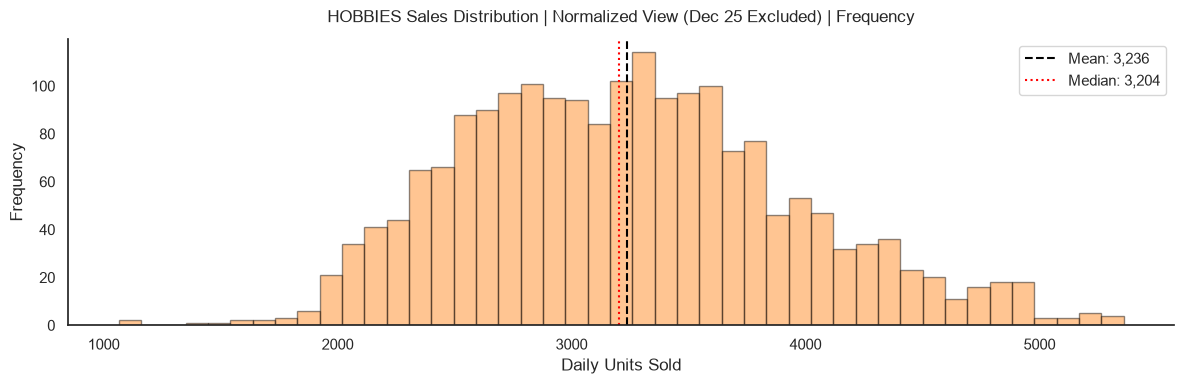

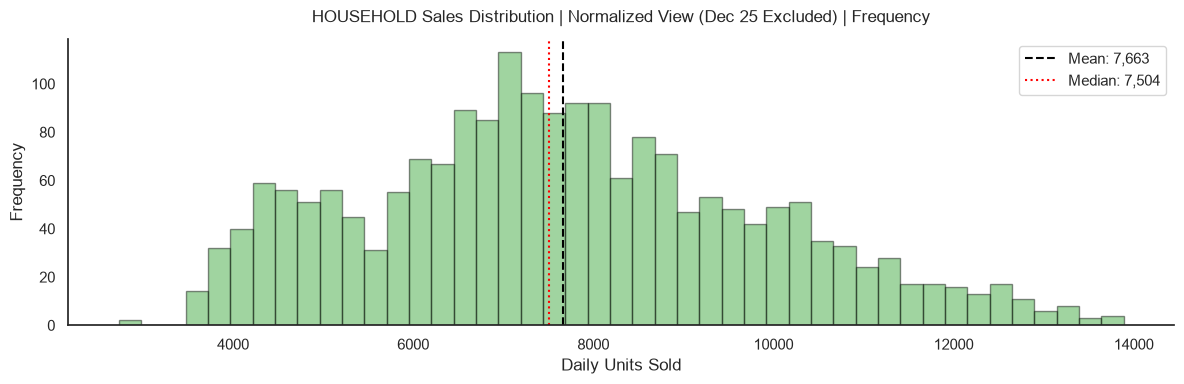

In [30]:
plot_category_histograms(category_daily_normalized, title_suffix="Normalized View (Dec 25 Excluded)", density=False)


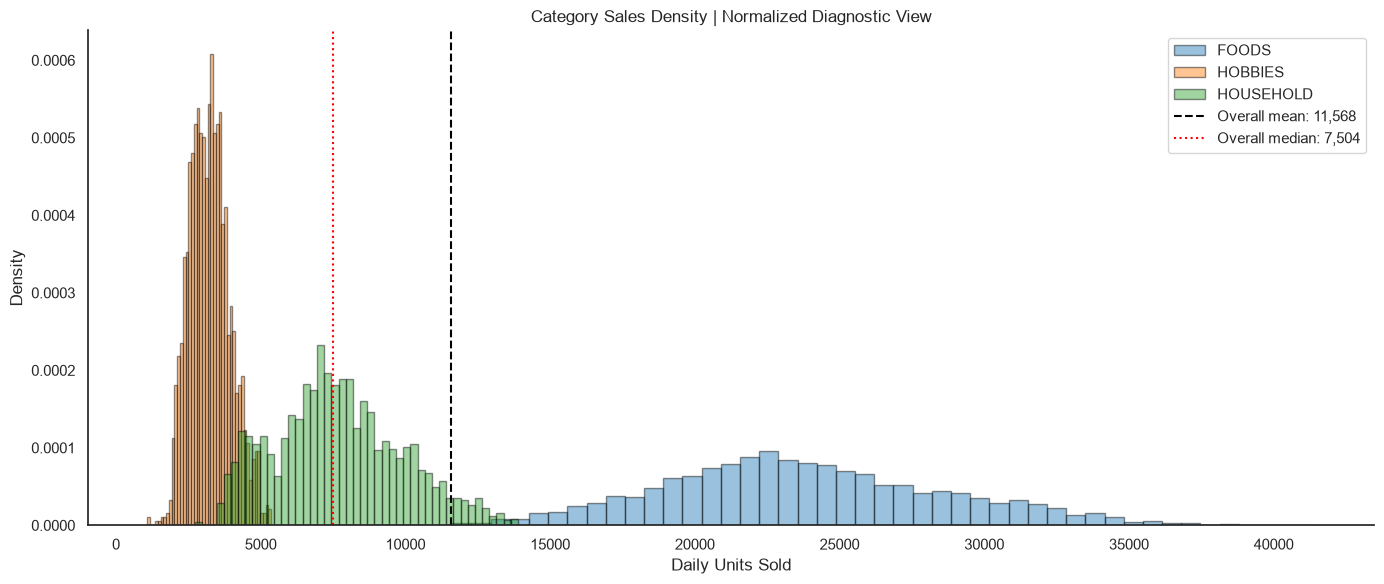

In [31]:
overall_mean = category_daily_normalized["y"].mean()
overall_median = category_daily_normalized["y"].median()

plt.figure(figsize=(14, 6))

for cat in sorted(category_daily_normalized["cat_id"].unique()):
    data = category_daily_normalized.loc[category_daily_normalized["cat_id"].eq(cat), "y"]
    plt.hist(
        data,
        bins="sqrt",
        density=True,
        alpha=0.45,
        edgecolor="black",
        label=cat,
        color=category_colors.get(cat, "tab:gray"),
    )

plt.axvline(overall_mean, color="black", linestyle="--", label=f"Overall mean: {overall_mean:,.0f}")
plt.axvline(overall_median, color="red", linestyle=":", label=f"Overall median: {overall_median:,.0f}")
plt.title("Category Sales Density | Normalized Diagnostic View")
plt.xlabel("Daily Units Sold")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


### Distribution interpretation

The category distributions are not interchangeable. `FOODS` operates at a much larger daily scale than `HOBBIES` or `HOUSEHOLD`, so category-level normalization and category-specific evaluation will matter later.


## 10. Seasonality diagnostics

Seasonality is more useful when viewed by category instead of only in the aggregate. This prevents the highest-volume category from dominating the interpretation.


In [32]:
seasonality_df = add_calendar_flags(category_daily_raw)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

category_dow_sales = (
    seasonality_df
    .groupby(["cat_id", "dayofweek"], observed=True)["y"]
    .mean()
    .reset_index()
)
category_dow_sales["dayofweek"] = pd.Categorical(
    category_dow_sales["dayofweek"],
    categories=weekday_order,
    ordered=True,
)
category_dow_sales = category_dow_sales.sort_values(["cat_id", "dayofweek"])

category_dow_sales


,cat_id,dayofweek,y
1,HOBBIES,Monday,"3,004.02"
5,HOBBIES,Tuesday,"2,874.98"
6,HOBBIES,Wednesday,"2,907.93"
4,HOBBIES,Thursday,"2,902.51"
0,HOBBIES,Friday,"3,348.49"
2,HOBBIES,Saturday,"3,960.68"
3,HOBBIES,Sunday,"3,593.63"
8,HOUSEHOLD,Monday,"7,209.74"
12,HOUSEHOLD,Tuesday,"6,576.71"
13,HOUSEHOLD,Wednesday,"6,501.07"


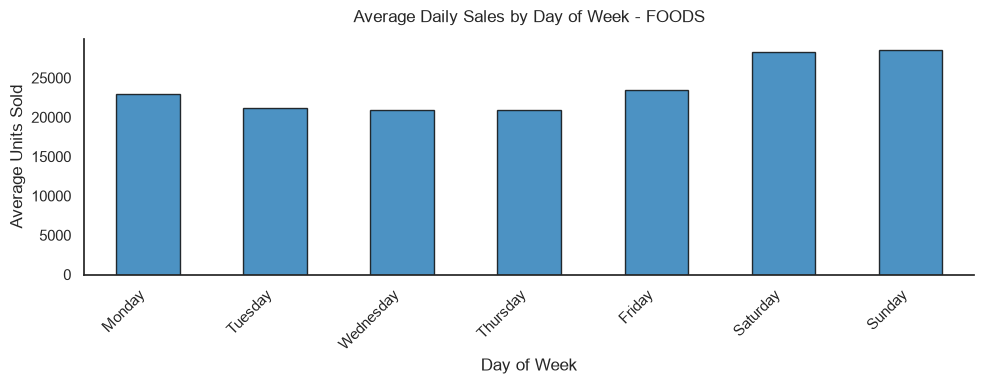

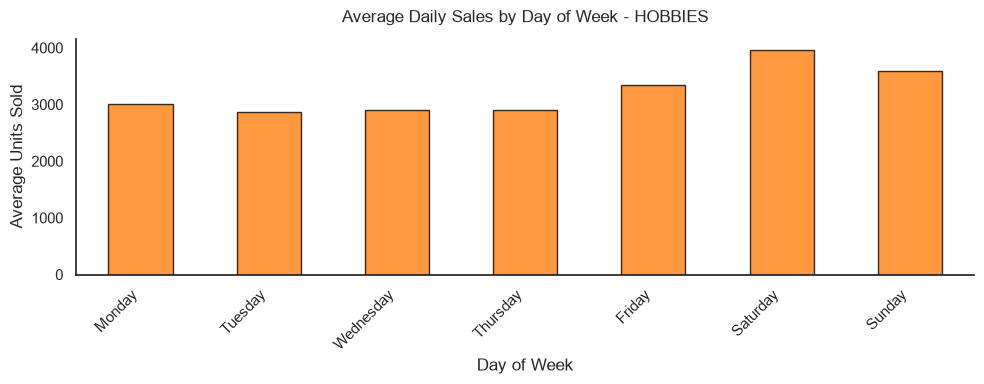

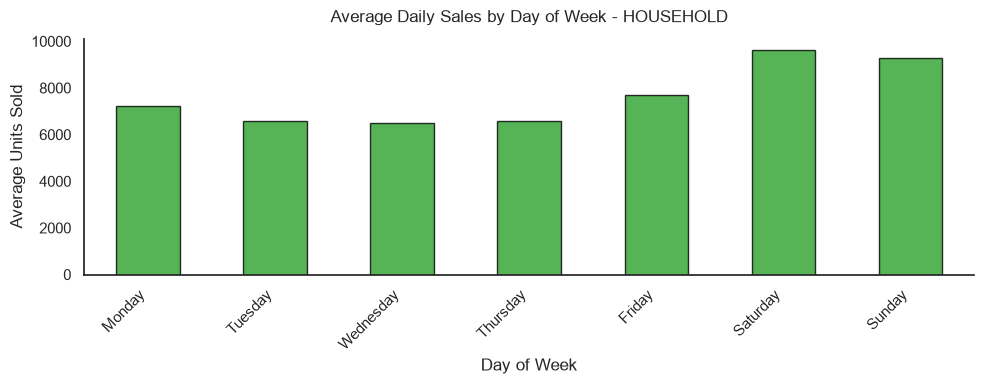

In [33]:
plot_category_bar_panels(
    category_dow_sales,
    x_col="dayofweek",
    y_col="y",
    title_prefix="Average Daily Sales by Day of Week",
    xlabel="Day of Week",
    ylabel="Average Units Sold",
    rotation=45,
)


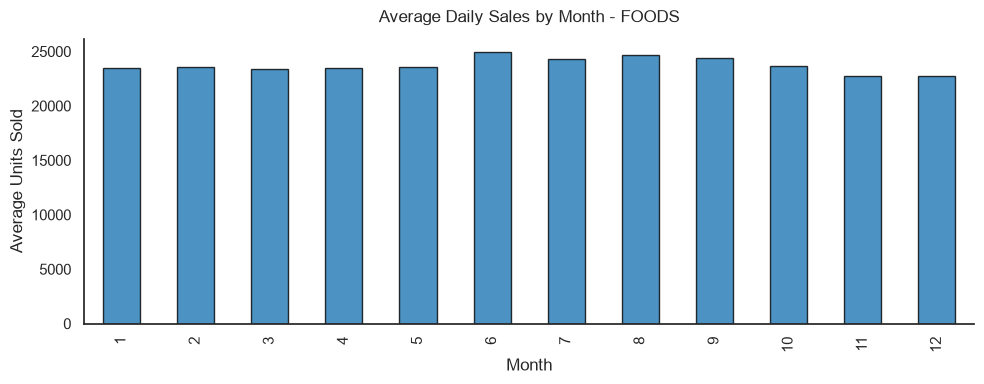

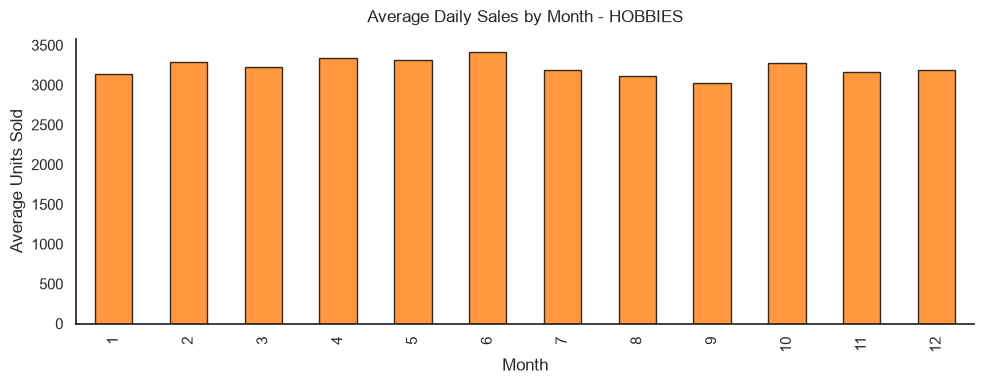

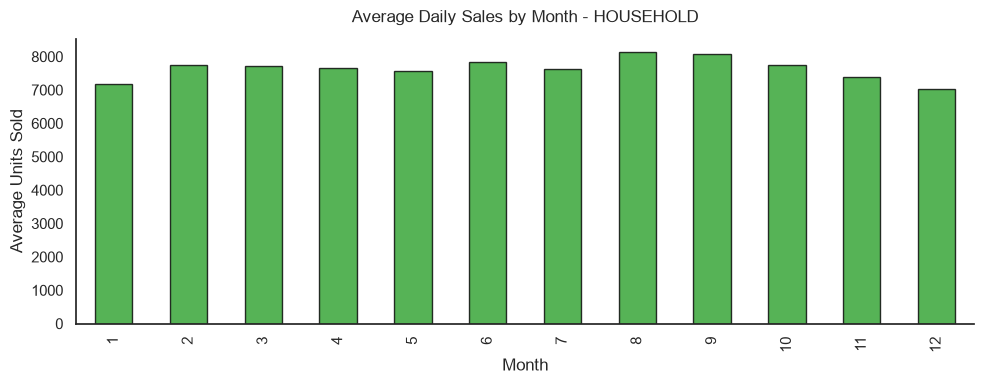

In [34]:
category_monthly_sales = (
    seasonality_df
    .groupby(["cat_id", "month"], observed=True)["y"]
    .mean()
    .reset_index()
)

plot_category_bar_panels(
    category_monthly_sales,
    x_col="month",
    y_col="y",
    title_prefix="Average Daily Sales by Month",
    xlabel="Month",
    ylabel="Average Units Sold",
)


## 11. Event and SNAP first pass

This section is intentionally light-touch. We only want a first look at event and SNAP context now. Deeper interpretation belongs in feature engineering, where we can evaluate whether these fields improve forecasts or inventory decisions.


In [35]:
event_sales = (
    m5
    .groupby(["cat_id", "event_type_1"], observed=True)["y"]
    .agg(mean="mean", median="median", count="count")
    .reset_index()
    .sort_values(["cat_id", "mean"], ascending=[True, False])
)

event_sales


,cat_id,event_type_1,mean,median,count
4,HOBBIES,nan,0.72,0.00,8205696
2,HOBBIES,Religious,0.71,0.00,248311
3,HOBBIES,Sporting,0.71,0.00,80971
0,HOBBIES,Cultural,0.71,0.00,166675
1,HOBBIES,National,0.54,0.00,238473
8,HOUSEHOLD,Sporting,0.92,0.00,150086
9,HOUSEHOLD,nan,0.91,0.00,15185146
7,HOUSEHOLD,Religious,0.90,0.00,461537
5,HOUSEHOLD,Cultural,0.88,0.00,310100
6,HOUSEHOLD,National,0.76,0.00,440492


In [36]:
snap_cols = ["snap_CA", "snap_TX", "snap_WI"]

snap_effects = []
for state, snap_col in zip(["CA", "TX", "WI"], snap_cols):
    tmp = (
        m5.loc[m5["state_id"].eq(state)]
        .groupby(["cat_id", snap_col], observed=True)["y"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
        .rename(columns={snap_col: "snap_flag"})
    )
    tmp["state_id"] = state
    tmp["snap_col"] = snap_col
    snap_effects.append(tmp)

snap_effects = pd.concat(snap_effects, ignore_index=True)
snap_effects.sort_values(["state_id", "cat_id", "snap_flag"])


,cat_id,snap_flag,mean,median,count,state_id,snap_col
0,HOBBIES,0,0.88,0.00,2379626,CA,snap_CA
1,HOBBIES,1,0.91,0.00,1168172,CA,snap_CA
2,HOUSEHOLD,0,1.00,0.00,4417787,CA,snap_CA
3,HOUSEHOLD,1,1.04,0.00,2170055,CA,snap_CA
4,FOODS,0,2.20,1.00,5852271,CA,snap_CA
5,FOODS,1,2.43,1.00,2876254,CA,snap_CA
6,HOBBIES,0,0.61,0.00,1805429,TX,snap_TX
7,HOBBIES,1,0.62,0.00,888315,TX,snap_TX
8,HOUSEHOLD,0,0.89,0.00,3348930,TX,snap_TX
9,HOUSEHOLD,1,0.92,0.00,1647997,TX,snap_TX


## 12. SKU-store intermittency and demand profile

Category demand can look smooth even when the underlying SKU-store series are sparse. This matters for retail replenishment because operational decisions happen closer to the series level than the category level.


In [37]:
series_profile = (
    m5
    .groupby("unique_id", observed=True)
    .agg(
        avg_daily_sales=("y", "mean"),
        median_daily_sales=("y", "median"),
        total_sales=("y", "sum"),
        zero_sales_rate=("y", lambda s: (s == 0).mean()),
        sales_std=("y", "std"),
        days_observed=("y", "count"),
    )
    .reset_index()
    .merge(S_df, on="unique_id", how="left")
)

series_profile.head()


,unique_id,avg_daily_sales,median_daily_sales,total_sales,zero_sales_rate,sales_std,days_observed,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,0.80,0.00,"1,570.00",0.56,1.27,1969,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_2,1.16,1.00,"2,287.00",0.48,1.78,1969,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
2,FOODS_1_001_CA_3,1.20,0.00,"2,367.00",0.55,2.33,1969,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
3,FOODS_1_001_CA_4,0.36,0.00,712.00,0.74,0.73,1968,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
4,FOODS_1_001_TX_1,0.59,0.00,"1,158.00",0.67,1.31,1968,FOODS_1_001,FOODS_1,FOODS,TX_1,TX


In [38]:
def demand_type(row):
    if row["zero_sales_rate"] >= 0.70:
        return "Very intermittent"
    if row["zero_sales_rate"] >= 0.40:
        return "Intermittent"
    if row["avg_daily_sales"] >= 5:
        return "High volume"
    return "Regular / low volume"


series_profile["demand_type"] = series_profile.apply(demand_type, axis=1)

series_profile["demand_type"].value_counts()


demand_type
Very intermittent       12294
Intermittent            11476
Regular / low volume     5329
High volume              1391
Name: count, dtype: int64

In [39]:
series_profile_by_category = (
    series_profile
    .groupby(["cat_id", "demand_type"], observed=True)
    .agg(
        series_count=("unique_id", "nunique"),
        avg_zero_rate=("zero_sales_rate", "mean"),
        avg_daily_sales=("avg_daily_sales", "mean"),
    )
    .reset_index()
    .sort_values(["cat_id", "series_count"], ascending=[True, False])
)

series_profile_by_category


,cat_id,demand_type,series_count,avg_zero_rate,avg_daily_sales
3,HOBBIES,Very intermittent,3582,0.84,0.22
1,HOBBIES,Intermittent,1604,0.57,0.92
2,HOBBIES,Regular / low volume,378,0.31,2.44
0,HOBBIES,High volume,86,0.25,7.02
7,HOUSEHOLD,Very intermittent,5134,0.83,0.22
5,HOUSEHOLD,Intermittent,3466,0.57,0.78
6,HOUSEHOLD,Regular / low volume,1599,0.27,2.17
4,HOUSEHOLD,High volume,271,0.12,8.45
9,FOODS,Intermittent,6406,0.55,1.03
11,FOODS,Very intermittent,3578,0.79,0.33


## 13. Price behavior

Price is part of the exogenous signal. At this stage, we only want a descriptive view of how much price movement exists and what one high-volume series looks like over time.


In [40]:
price_profile = (
    m5
    .groupby("unique_id", observed=True)
    .agg(
        avg_price=("sell_price", "mean"),
        min_price=("sell_price", "min"),
        max_price=("sell_price", "max"),
        price_changes=("sell_price", "nunique"),
        total_sales=("y", "sum"),
    )
    .reset_index()
    .merge(S_df, on="unique_id", how="left")
)

price_profile.sort_values("price_changes", ascending=False).head(20)


,unique_id,avg_price,min_price,max_price,price_changes,total_sales,item_id,dept_id,cat_id,store_id,state_id
936,FOODS_1_095_TX_3,4.11,3.44,4.62,21,"1,828.00",FOODS_1_095,FOODS_1,FOODS,TX_3,TX
934,FOODS_1_095_TX_1,4.12,3.44,4.62,21,280.00,FOODS_1_095,FOODS_1,FOODS,TX_1,TX
1267,FOODS_1_129_WI_1,8.00,5.04,9.00,20,"2,497.00",FOODS_1_129,FOODS_1,FOODS,WI_1,WI
935,FOODS_1_095_TX_2,4.10,3.44,4.62,18,811.00,FOODS_1_095,FOODS_1,FOODS,TX_2,TX
930,FOODS_1_095_CA_1,3.03,2.66,3.42,18,403.00,FOODS_1_095,FOODS_1,FOODS,CA_1,CA
931,FOODS_1_095_CA_2,3.03,2.66,3.42,18,915.00,FOODS_1_095,FOODS_1,FOODS,CA_2,CA
1269,FOODS_1_129_WI_3,8.03,5.04,9.00,18,"2,994.00",FOODS_1_129,FOODS_1,FOODS,WI_3,WI
1268,FOODS_1_129_WI_2,8.01,7.02,9.00,18,"5,062.00",FOODS_1_129,FOODS_1,FOODS,WI_2,WI
933,FOODS_1_095_CA_4,3.03,2.66,3.42,18,"1,411.00",FOODS_1_095,FOODS_1,FOODS,CA_4,CA
948,FOODS_1_096_WI_2,7.99,7.02,9.00,17,"32,593.00",FOODS_1_096,FOODS_1,FOODS,WI_2,WI


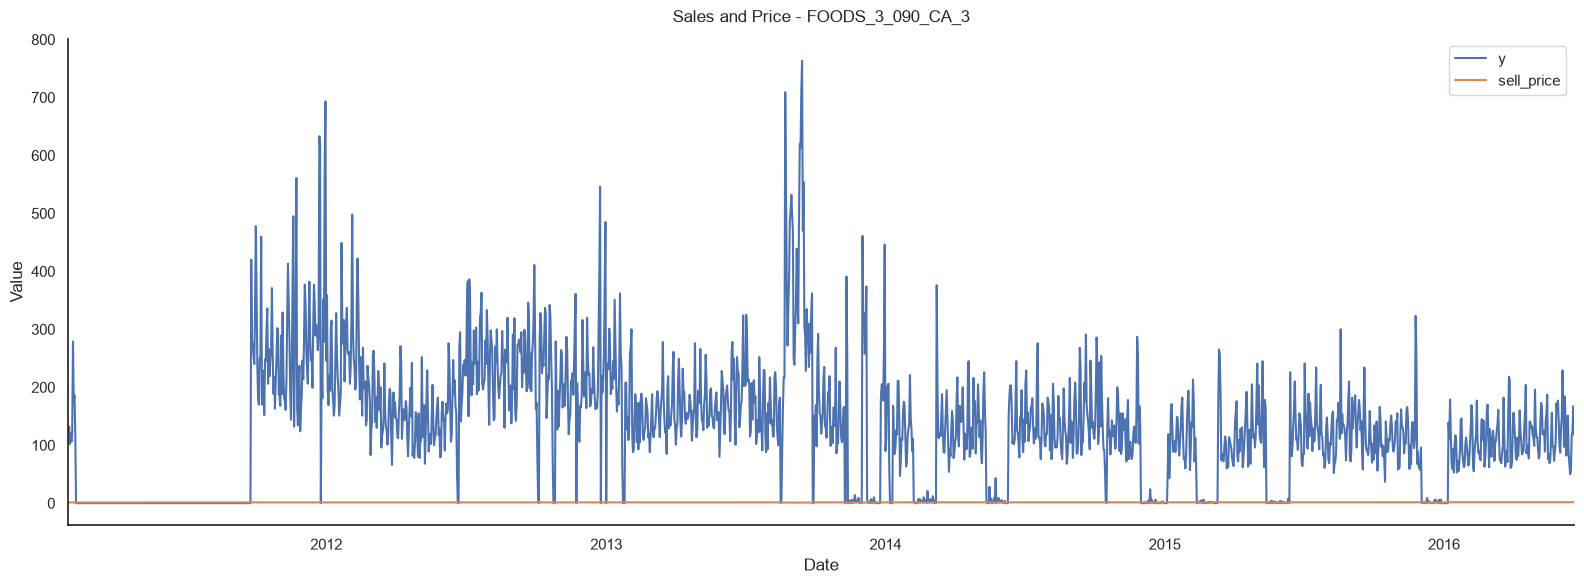

In [41]:
sample_id = series_profile.sort_values("total_sales", ascending=False)["unique_id"].iloc[0]
sample = m5.loc[m5["unique_id"].eq(sample_id)].copy().sort_values("ds")

ax = sample.plot(
    x="ds",
    y=["y", "sell_price"],
    figsize=(16, 6),
    title=f"Sales and Price - {sample_id}",
)
finish_axis(ax, title=f"Sales and Price - {sample_id}", xlabel="Date", ylabel="Value")
plt.show()


## 14. Simple baseline forecasting sanity check

This is still exploratory. The point is not to optimize a model yet, but to get a rough sense of how predictable category-level demand looks under very simple benchmarks.


In [42]:
H = 28


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom


def evaluate_baselines_one_series(df: pd.DataFrame, h: int = 28) -> list[dict]:
    df = df.sort_values("ds")
    train = df.iloc[:-h].copy()
    test = df.iloc[-h:].copy()

    forecasts = {
        "naive_last": train["y"].iloc[-1],
        "ma_28": train["y"].tail(28).mean(),
        "ma_56": train["y"].tail(56).mean(),
    }

    rows = []
    for model_name, pred in forecasts.items():
        y_pred = np.repeat(pred, len(test))
        rows.append(
            {
                "model": model_name,
                "mae": mae(test["y"].to_numpy(), y_pred),
                "wape": wape(test["y"].to_numpy(), y_pred),
            }
        )
    return rows


In [43]:
baseline_results = []

for cat in sorted(category_daily_raw["cat_id"].unique()):
    df = category_daily_raw.loc[category_daily_raw["cat_id"].eq(cat), ["ds", "y"]].copy()
    for row in evaluate_baselines_one_series(df, h=H):
        row["cat_id"] = cat
        baseline_results.append(row)

baseline_results = pd.DataFrame(baseline_results)
baseline_results.sort_values(["cat_id", "wape"])


,model,mae,wape,cat_id
2,ma_56,"2,870.38",0.10,FOODS
1,ma_28,"2,913.96",0.10,FOODS
0,naive_last,"6,576.29",0.22,FOODS
5,ma_56,397.78,0.10,HOBBIES
4,ma_28,414.35,0.10,HOBBIES
3,naive_last,"1,161.50",0.28,HOBBIES
8,ma_56,"1,151.77",0.11,HOUSEHOLD
7,ma_28,"1,155.59",0.11,HOUSEHOLD
6,naive_last,"2,891.93",0.28,HOUSEHOLD


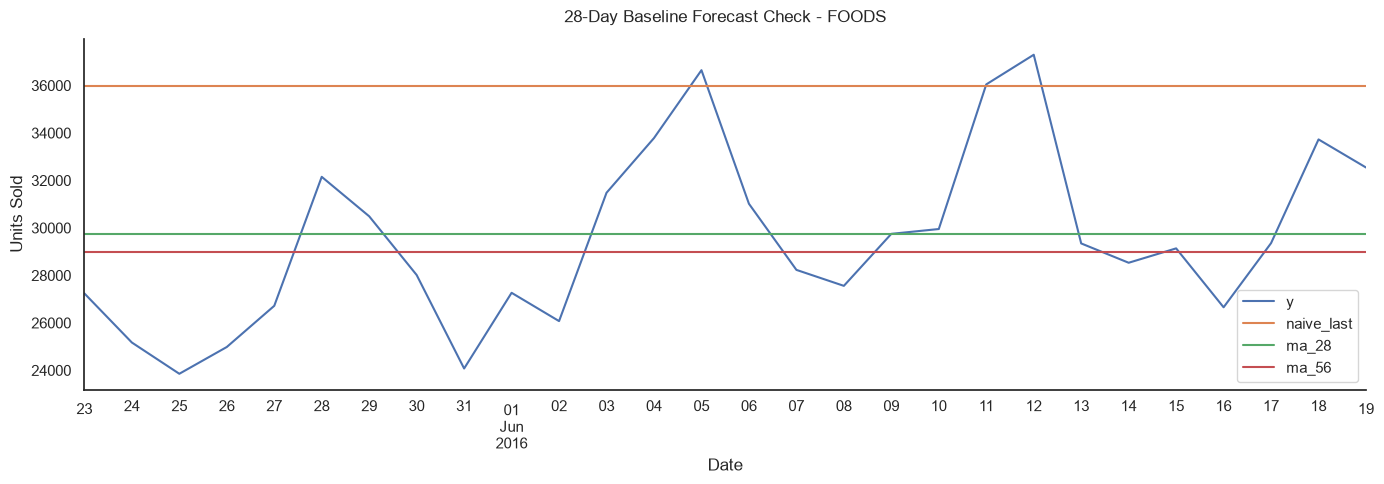

In [44]:
cat = "FOODS"
df = category_daily_raw.loc[category_daily_raw["cat_id"].eq(cat), ["ds", "y"]].sort_values("ds").copy()
train = df.iloc[:-H].copy()
test = df.iloc[-H:].copy()

plot_df = test.copy()
plot_df["naive_last"] = train["y"].iloc[-1]
plot_df["ma_28"] = train["y"].tail(28).mean()
plot_df["ma_56"] = train["y"].tail(56).mean()

ax = plot_df.plot(x="ds", y=["y", "naive_last", "ma_28", "ma_56"], figsize=(14, 5))
finish_axis(ax, title=f"28-Day Baseline Forecast Check - {cat}", xlabel="Date", ylabel="Units Sold")
plt.show()


## 15. Save processed analytical tables

These outputs make the next notebooks easier to build because they preserve the main EDA-level aggregates without repeating the joins and groupbys each time.


In [45]:
category_daily_raw.to_parquet(PROCESSED_DIR / "category_daily_raw.parquet", index=False)
category_daily_event_adjusted.to_parquet(
    PROCESSED_DIR / "category_daily_event_adjusted.parquet",
    index=False,
)
category_daily_normalized.to_parquet(
    PROCESSED_DIR / "category_daily_normalized_excluding_christmas.parquet",
    index=False,
)
store_category_daily.to_parquet(PROCESSED_DIR / "store_category_daily.parquet", index=False)
state_category_daily.to_parquet(PROCESSED_DIR / "state_category_daily.parquet", index=False)
series_profile.to_parquet(PROCESSED_DIR / "series_profile.parquet", index=False)

print("Saved processed tables to", PROCESSED_DIR)


Saved processed tables to data/processed


## 16. Current EDA Conclusions

Preliminary conclusions from this first pass:

1. The three M5 tables join cleanly, and this EDA pass found no duplicate `unique_id`-date rows, no negative sales, and no missing target values in `Y_df`.
2. Category demand operates at clearly different scales, with `FOODS` far above `HOUSEHOLD`, and `HOUSEHOLD` above `HOBBIES`, so later evaluation should stay category-aware.
3. December 25 behaves like an extreme calendar effect with near-zero category sales, but it remains in the raw data; only the normalized diagnostic view excludes it.
4. Category-level demand is smoother than the underlying SKU-store series, while many SKU-store histories still show intermittent behavior.
5. Event and SNAP fields deserve a more careful pass in feature engineering, but this notebook stops at a descriptive first look rather than making causal claims.
